# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch as pt

from torch.utils.data import random_split, DataLoader
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import sys

In [2]:
sys.path.append(r"D:\Materials\AI\Projects\Lib\torchwires\src")

from torchwires import Repo, Visualizer, Runner, PassState

# Dataset & Loaders

In [3]:
class DictDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]

        return {
            "x": x,
            "y": y,
        }

In [4]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_dataset, val_dataset, test_dataset, _ = random_split(
    full_train_dataset,
    [1000, 300, 300, len(full_train_dataset) - 1600],
)

train_dataset = DictDataset(train_dataset)
val_dataset = DictDataset(val_dataset)
test_dataset = DictDataset(test_dataset)

In [5]:
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)

# Repo Layout

## Definition

In [6]:
repo = Repo(
    repo_name='repo_0',
)

History cache not found: path=repo_0\exp_1\history.json


## Model

In [7]:
class ClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(1 * 28 * 28, 10)

    def forward(self, x):
      
        u = self.flatten(x)
        u1 = self.fc1(u)

        return u1

In [8]:
cls_model =  ClassifierModel()

repo.register(
    name='classifier-m',
    value=cls_model
)

Model classifier-m: has been registered
Model classifier-m weights not found: path=repo_0\exp_1\last\classifier-m.weights.pth


## Optimizer

In [9]:
repo.register(
    name='opt-cls',
    value= torch.optim.Adam(cls_model.parameters(), lr=0.001)
)

Optimizer opt-cls: has been registered
Optimizer opt-cls cache not found: path=repo_0\exp_1\last\opt-cls.optimizer.pth


# State

In [11]:
class AppState(PassState):
    x = None
    y = None
    y_hat = None
    ce_loss = None
    accuracy = None

## Nodes

In [12]:
def model_pass_node(state: AppState):    
    y_hat = cls_model(state.x)
    
    return {
        'y_hat': y_hat
    }
    

repo.wire(
    name='model-pass',
    body=model_pass_node,
)

Node model-pass: has been registered


In [13]:
def ce_node(state: AppState):
    ce_loss = F.cross_entropy(state.y_hat, state.y)
    
    return {
        'ce_loss': ce_loss
    }
    

repo.wire(
    name='ce_node',
    body=ce_node,
    tracked_features=['ce_loss']
)

Node ce_node: has been registered
Observer tracks: feature=ce_loss


In [14]:
def acc_node(state: AppState):
    accuracy = state.y_hat.argmax(dim=1).eq(state.y).float().mean()
    
    return {
        'accuracy': accuracy
    }
    

repo.wire(
    name='acc_node',
    body=acc_node,
    tracked_features=['accuracy']
)

Node acc_node: has been registered
Observer tracks: feature=accuracy


# Cache Load

In [15]:
repo.load()

Model classifier-m weights not found: path=repo_0\exp_1\last\classifier-m.weights.pth
Optimizer opt-cls cache not found: path=repo_0\exp_1\last\opt-cls.optimizer.pth
History cache not found: path=repo_0\exp_1\history.json


# Training

In [16]:
runner = Runner(
    repo=repo
)

Runner has been initialized: last complete epoch=None


## cb

In [17]:
# runner.enable_autosave(
#     interval=2,
# )

In [18]:
runner.enable_checkpointing(
    split='val',
    monitor='ce_loss',
    aggregate_mode='mean',
    mode='min'
)

In [19]:
# runner.enable_early_stopping(
#     split= 'val',
#     monitor='accuracy',
#     patience=3,
#     aggregate_mode='mean',
#     mode='max'
# )

## train

In [20]:
runner.train(
    epochs=25,
    backprob_losses=['ce_loss'],
    device='cpu',
    train_loader=train_loader,
    val_loader=val_loader
)

Start training: from epoch=0 to epoch=25

epoch:0 | batch:19 | split:train | device:cpu | ce_loss:1.6682690382003784 | accuracy:0.7400000095367432 
epoch:0 | batch:5 | split:val | device:cpu | ce_loss:1.726515769958496 | accuracy:0.6399999856948853     
Checkpoint: val-ce_loss improved from inf to 1.6873393058776855 | checkpoint name: checkpoint val-ce_loss-min
Model classifier-m weights saved: path=repo_0\exp_1\checkpoint val-ce_loss-min\classifier-m.weights.pth
Optimizer opt-cls weights saved: path=repo_0\exp_1\checkpoint val-ce_loss-min\opt-cls.optimizer.pth
History saved: json=repo_0\exp_1\history.json

epoch:1 | batch:19 | split:train | device:cpu | ce_loss:1.3097164630889893 | accuracy:0.8399999737739563 
epoch:1 | batch:5 | split:val | device:cpu | ce_loss:1.3383092880249023 | accuracy:0.7599999904632568    
Checkpoint: val-ce_loss improved from 1.6873393058776855 to 1.4951080083847046 | checkpoint name: checkpoint val-ce_loss-min
Model classifier-m weights saved: path=repo_0\ex

# Save

In [21]:
repo.save()

Model classifier-m weights saved: path=repo_0\exp_1\last\classifier-m.weights.pth
Optimizer opt-cls weights saved: path=repo_0\exp_1\last\opt-cls.optimizer.pth
History saved: json=repo_0\exp_1\history.json


# Visuals

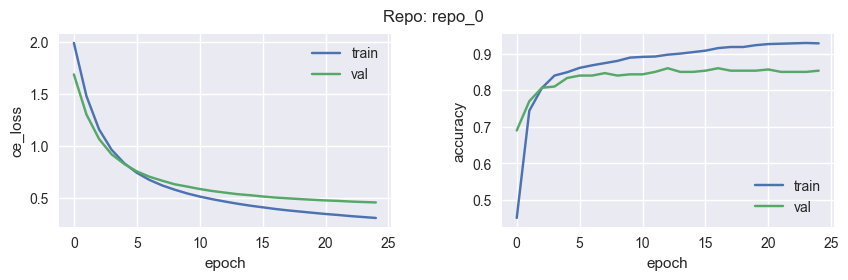

In [22]:
Visualizer.visualize_repo(
    repo=repo,
    n_cols=2
)

In [23]:
Visualizer.display_df(
    repo=repo
)

ce_loss  accuracy
epoch split                    
0     train  1.989127  0.451000
      val    1.687339  0.690000
1     train  1.479010  0.744000
      val    1.302876  0.770000
2     train  1.160764  0.806000
      val    1.068439  0.806667
3     train  0.964089  0.840000
      val    0.920454  0.810000
4     train  0.835464  0.849000
      val    0.828580  0.833333
5     train  0.743799  0.861000
      val    0.757260  0.840000
6     train  0.675597  0.868000
      val    0.706163  0.840000
7     train  0.623407  0.874000
      val    0.668589  0.846667
8     train  0.581941  0.880000
      val    0.633844  0.840000
9     train  0.545882  0.889000
      val    0.611562  0.843333
10    train  0.515810  0.891000
      val    0.588297  0.843333
11    train  0.490454  0.892000
      val    0.568890  0.850000
12    train  0.468003  0.897000
      val    0.553697  0.860000
13    train  0.447096  0.900000
      val    0.538770  0.850000
14    train  0.428591  0.904000
      val    0.528611  0.850000
15    train  0.412737  0.908000
      val    0.516667  0.853333
16    train  0.396779  0.915000
      val    0.506106  0.860000
17    train  0.383183  0.918000
      val    0.498824  0.853333
18    train  0.371557  0.918000
      val    0.491327  0.853333
19    train  0.359820  0.923000
      val    0.484822  0.853333
20    train  0.348617  0.926000
      val    0.478625  0.856667
21    train  0.339045  0.927000
      val    0.474114  0.850000
22    train  0.328250  0.928000
      val    0.467758  0.850000
23    train  0.319343  0.929000
      val    0.463310  0.850000
24    train  0.310314  0.928000
      val    0.459234  0.853333

# Predict

In [24]:
x, y = test_dataset[0]['x'], test_dataset[0]['y']

x = pt.stack([x])
y = pt.tensor([y])

s = runner.inference(
    device='cpu',
    inputs={
        'x': x,
        'y': y
    }
)

print(s.keys())

dict_keys(['epoch', 'batch', 'split', 'device', 'x', 'y', 'y_hat', 'ce_loss', 'accuracy'])
